In [1]:
import os
import dill
import itertools
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import pickle


import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u
from STX3KO_analyses import utilities_ES as u_es
from STX3KO_analyses.hse import HSE
import TwoPUtils as tpu

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['font.serif'] = 'Arial'


%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
hse_dict = {}
basedir = '/home/mplitt/YMazeReplayPkls_F_dff/'
for cond_key, mice in zip(('ctrl', 'cre'),(ctrl_mice, ko_mice)):
    hse_dict[cond_key] = {}
    for day in range(6):
        hse_dict[cond_key][day] = {}
        for mouse in mice:
            filename = basedir + f'{mouse}_day{day}.pkl'
            hse_dict[cond_key][day][mouse]=filename

In [12]:
def get_cell_orders(mouse, session_deets, days, match_inds):
    if mouse in ctrl_mice:
        cond_key='ctrl'
    else:
        cond_key='cre'
            
    
    cell_order = []
    for day in days:
        deets = session_deets[day]
        if isinstance(deets,tuple):
            roi_inds = []
            for _deets in deets:
                roi_inds.append(_deets['ravel_ind'])
            print(roi_inds)
            mapping = u.common_rois(match_inds, roi_inds)
            
            cell_order.append(mapping[0,:].tolist())
        else:
            cell_order.append([])
    return cell_order

def common_rois_adjust(mouse, days):
    if mouse in ctrl_mice:
        session_deets = stx.ymaze_sess_deets.CTRL_sessions[mouse]
    else:
        session_deets = stx.ymaze_sess_deets.KO_sessions[mouse]
    
    
    ravel_inds = []
    day_inds = []
    for day in days:
        deets = session_deets[day]
        if isinstance(deets, tuple):
            for _deets in deets:
                ravel_inds.append(_deets['ravel_ind'])
                day_inds.append(day)
        else:
            ravel_inds.append(deets['ravel_ind'])
            day_inds.append(day)

    pkldir = os.path.join('/home/mplitt/YMazeSessPkls/', mouse)
    with open(os.path.join(pkldir, "roi_aligner_results.pkl"), 'rb') as file:
        match_inds = dill.load(file)
    

    common_roi_mapping = u.common_rois(match_inds, ravel_inds)
    c_rows = []
    for i, d in enumerate(day_inds):
        if d != day_inds[i-1]:
            c_rows.append(i)
    
    common_roi_mapping = common_roi_mapping[c_rows,:]
    cell_order = get_cell_orders(mouse,session_deets, days, match_inds)

    roi_mapping_adj = np.zeros(common_roi_mapping.shape)
    c_cols = []
    for row, order in enumerate(cell_order):
        croi = common_roi_mapping[row,:]

        if len(order)==0:
            roi_mapping_adj[row,:] = croi
        else:
            for col, _c in enumerate(croi):
                match = np.argwhere(order==_c)
                if len(match)>0:
                    c_cols.append(col)
                    roi_mapping_adj[row,col]=match[0][0]
                    
                    
    if len(c_cols) !=0:
        roi_mapping_adj = roi_mapping_adj[:,c_cols]
    return roi_mapping_adj.astype(int)


def predict_future_tt_stability(mouse):
    print(mouse)
    if mouse in ctrl_mice:
        cond_key='ctrl'
    else:
        cond_key='cre'
    corr_dict = {}
    for react_day in range(6):

        corr_dict[react_day] = {}

        for tt_corr_day in range(react_day,6):
        
            corr_dict[react_day][tt_corr_day] ={}
            
            days = [react_day, tt_corr_day]
            
            if react_day == tt_corr_day:
                
                with open(hse_dict[cond_key][react_day][mouse], 'rb') as file:
                    hse_react = pickle.load(file)
                    hse_tt_corr = hse_react
                    
                common_roi_mapping = np.array([np.arange(hse_react.spks.shape[0]) for _ in range(2)])
                
            else:
                common_roi_mapping = common_rois_adjust(mouse, days)


                with open(hse_dict[cond_key][react_day][mouse], 'rb') as file:
                    hse_react = pickle.load(file)

                # trial matrix 
                with open(hse_dict[cond_key][tt_corr_day][mouse], 'rb') as file:
                    hse_tt_corr = pickle.load(file)
                
            for key  in ('fam', 'nov'):
                corr_dict[react_day][tt_corr_day][key] = {}
                   
                # reactivation mask
                if key == 'fam':
                    trial_mask = hse_tt_corr.trial_info["LR"]!=hse_tt_corr.novel_arm
                    lr_mask = hse_react.lr!=hse_react.novel_arm
                else:
                    trial_mask = hse_tt_corr.trial_info["LR"]==hse_tt_corr.novel_arm
                    lr_mask = hse_react.lr==hse_react.novel_arm
                

                boxcar = np.ones([1,4]) # 500 ms window
        # self.post_reward_activation_boxcar = sp.signal.convolve(self.post_reward_activation_mask,boxcar,mode='same')
        # self.pop_coactivity_boxcar = self.post_reward_activation_boxcar.sum(axis=0)
        
                # react_spks_ledge = 1*(np.diff(1.*(hse_react.spks_th>0),prepend=0,axis=-1)>0)
                ts_mask = lr_mask * (hse_react.post_reward_bool>0)
                # print(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask].shape,
                #       hse_react.post_reward_activation_boxcar[common_roi_mapping[0,:],:][:,ts_mask].shape)
                
                if ts_mask.sum()<10:
                    corr_dict[react_day][tt_corr_day][key]['tt_corr']=[np.nan,]
                    corr_dict[react_day][tt_corr_day][key]['hse_corr']=[np.nan,]
                    continue
                # print(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask].shape,
                #       hse_react.post_reward_activation_boxcar[common_roi_mapping[0,:],:][:,ts_mask].shape)

                r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
                                        hse_react.post_reward_activation_boxcar[common_roi_mapping[0,:],:][:,ts_mask], axis=-1)
               
                
                trial_mat = hse_tt_corr.trial_mat[trial_mask,:,:][:,:,common_roi_mapping[1,:]]
                trial_mat[np.isnan(trial_mat)]=0
                corr_mat = np.zeros([trial_mat.shape[0], trial_mat.shape[0], trial_mat.shape[-1]])

                for cell in range(trial_mat.shape[-1]):
                    corr_mat[:,:,cell] = np.corrcoef(trial_mat[:,:,cell])

                for cell in range(corr_mat.shape[-1]):
                    _mat = corr_mat[:, :,cell]
                    _mat[np.diag_indices_from(_mat)]=np.nan
                    corr_mat[:, :,cell] = _mat

                corr_dict[react_day][tt_corr_day][key]['tt_corr']=np.array([np.nanmean(np.nanmean(corr_mat,axis=0),axis=0)]).flatten()
                corr_dict[react_day][tt_corr_day][key]['hse_corr']=np.array([r]).flatten()
                
    return corr_dict

def predict_across_day_stability(mouse):
    print(mouse)
    if mouse in ctrl_mice:
        cond_key='ctrl'
    else:
        cond_key='cre'
    corr_dict = {}
    # common_roi_mapping = common_rois_adjust(mouse, np.arange(6))
    for react_day in range(5):
        corr_dict[react_day] = {}
        for tt_corr_day in range(react_day+1,6):
            corr_dict[react_day][tt_corr_day] ={}
            days = [react_day, tt_corr_day]

            common_roi_mapping = common_rois_adjust(mouse, days)
            


            with open(hse_dict[cond_key][react_day][mouse], 'rb') as file:
                hse_react = pickle.load(file)

            
            
            # trial matrix 
            with open(hse_dict[cond_key][tt_corr_day][mouse], 'rb') as file:
                hse_fut = pickle.load(file)
              
            
            for key  in ('fam', 'nov'):
                corr_dict[react_day][tt_corr_day][key] = {}
                
                if key == 'fam':
                    trial_mask_react = hse_react.trial_info['LR']!=hse_react.novel_arm
                    trial_mask_fut = hse_fut.trial_info['LR']!=hse_fut.novel_arm
                else:
                    trial_mask_react = hse_react.trial_info['LR']==hse_react.novel_arm
                    trial_mask_fut = hse_fut.trial_info['LR']==hse_fut.novel_arm

                tmat_react = np.nanmean(hse_react.trial_mat[trial_mask_react, :, :][:, :, common_roi_mapping[0,:]], axis=0)
                tmat_fut = np.nanmean(hse_fut.trial_mat[trial_mask_fut, :, :][:, :, common_roi_mapping[1,:]], axis=0)

                tmat_react[np.isnan(tmat_react)]=0
                tmat_fut[np.isnan(tmat_fut)]=0
                

                react_spks_ledge = 1*(np.diff(1.*(hse_react.spks_th>0),prepend=0,axis=-1)>0)
                
                hse_r,_ = sp.stats.pearsonr(hse_react.activation_mask.sum(axis=0)[np.newaxis,hse_react.post_reward_bool>0],
                                        react_spks_ledge[:,hse_react.post_reward_bool>0][common_roi_mapping[0,:],:], axis=-1)
                

                
                cell_r, _ = sp.stats.pearsonr(tmat_react, tmat_fut, axis=0)

                


                corr_dict[react_day][tt_corr_day][key]['cell_corr']=np.array([cell_r]).ravel()
                corr_dict[react_day][tt_corr_day][key]['hse_corr']=np.array([hse_r]).ravel()
                # except:
                #     corr_dict[react_day][tt_corr_day][key]['activated']=np.nan
                #     corr_dict[react_day][tt_corr_day][key]['nonactivated']=np.nan
                    
    return corr_dict


In [6]:
corr_dict = predict_future_tt_stability(ctrl_mice[1])

4467331.2
(1, 2821) (1283, 2821)


/tmp/ipykernel_210736/12318427.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],


(1, 280) (1283, 280)
(1, 2821) (787, 2821)


/tmp/ipykernel_210736/12318427.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],


(1, 280) (787, 280)
(1, 2821) (722, 2821)


...

(1, 691) (1033, 691)
(1, 3744) (639, 3744)


/tmp/ipykernel_210736/12318427.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],


(1, 691) (639, 691)
(1, 617) (982, 617)


/tmp/ipykernel_210736/12318427.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],


(1, 361) (982, 361)


[        nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan  0.24475089         nan
         nan         nan         nan -0.03843196 -0.0043223   0.11731861
         nan         nan         nan         nan         nan         nan
  0.24475089         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
  0.11731861         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
  0.11058792         nan         nan         nan -0.02427282         nan
         nan         nan -0.03843196  0.11731861  0.18564371         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan -0.02427282   

ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 1 dimension(s) and the array at index 12 has 0 dimension(s)

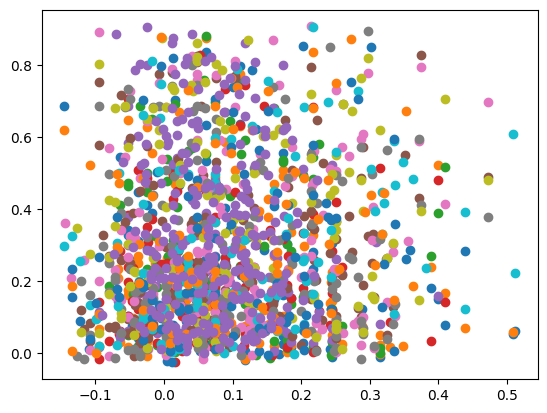

In [7]:
fig, ax = plt.subplots()
hse_corrs = []
tt_corrs = []
for i in range(5):
    for j in range(i+1,6):
        
        hse_corr = corr_dict[i][j]['nov']['hse_corr']
        tt_corr =  corr_dict[i][j]['nov']['tt_corr']
        print(hse_corr)
        hse_corrs.append(hse_corr)
        tt_corrs.append(tt_corr)
        ax.scatter(hse_corr,tt_corr)

hse_corrs = np.concatenate(hse_corrs)
tt_corrs = np.concatenate(tt_corrs)
        # nanmask = np.isnan(hse_corr*tt_corr)
        # print(f'days {i} {j}:', sp.stats.spearmanr(hse_corr[~nanmask],tt_corr[~nanmask]))
# ttday = 4
# hseday = 0

# hse_corr = corr_dict[hseday][ttday]['nov']['hse_corr']
# tt_corr =  corr_dict[hseday][ttday]['nov']['tt_corr']
# ax.scatter(hse_corr,tt_corr)
# nanmask = np.isnan(hse_corr*tt_corr)
# print(sp.stats.spearmanr(hse_corr[~nanmask],tt_corr[~nanmask]))

In [101]:
# hse_corrs = np.concatenate(hse_corrs)
# tt_corrs = np.concatenate(tt_corrs)
nanmask = ~np.isnan(hse_corrs*tt_corrs)
r, p = sp.stats.spearmanr(hse_corrs[nanmask], tt_corrs[nanmask])
print(f'Overall spearman r: {r}, p={p}')

Overall spearman r: 0.09505119181150731, p=1.0847429753349716e-10


In [19]:
rows = []
for cond, mice in zip(('ctrl','cre'), (ctrl_mice, ko_mice)):
    for mouse in mice:
        print(mouse)
        corr_dict = predict_future_tt_stability(mouse)
        for i in range(5):
            for j in range(i+1,6):
                
                hse_corr = corr_dict[i][j]['nov']['hse_corr']
                tt_corr =  corr_dict[i][j]['nov']['tt_corr']
                # print(hse_corr.shape)
                
                nanmask = np.isnan(np.array(hse_corr).flatten()*np.array(tt_corr).flatten())
                nanmask = np.array([nanmask,]).ravel()
                if nanmask.shape[0]==1:
                    continue
                print(hse_corr)
                hse_corr[nanmask] = 0
             

                for hse, tt in zip(hse_corr, tt_corr):
                    rows.append({'condition':cond,
                                 'mouse':mouse,
                                 'hse_day':i,
                                 'tt_day':j,
                                 'hse_corr':hse,
                                 'tt_corr':tt})
df = pd.DataFrame(rows)


4467331.1
4467331.1


/tmp/ipykernel_210736/3395728334.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_210736/3395728334.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_210736/3395728334.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_210736/3395728334.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_210736/3395728334.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = s

[        nan -0.00833234         nan  0.05863308 -0.19491389         nan
 -0.11390735         nan  0.17738847         nan         nan         nan
         nan         nan  0.14059711         nan         nan  0.07402543
         nan         nan         nan  0.13040527         nan         nan
         nan  0.02704224         nan         nan         nan         nan
         nan         nan  0.26420492         nan         nan         nan
  0.06462879         nan         nan         nan         nan         nan
  0.24784984         nan         nan         nan  0.10207322  0.11239712
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan  0.06634896         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
  0.12158485         nan         nan         nan   

/tmp/ipykernel_210736/3395728334.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_210736/3395728334.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_210736/3395728334.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],


[3, 4]


...

[       nan        nan        nan ... 0.16066609        nan        nan]
[        nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
  0.03706468  0.07664222  0.01067965  0.10053445  0.13600852  0.22598474
         nan         nan         nan -0.05710809         nan         nan
         nan         nan         nan -0.02230163         nan         nan
         nan         nan         nan -0.06687534  0.02387217 -0.05050144
         nan         nan  0.41253737         nan         nan         nan
         nan -0.10805296         nan  0.17558606         nan         nan
         nan  0.17943654 -0.04868665         nan         nan         nan
         nan -0.0739645          nan         nan         nan         nan
  0.07150647         nan  0.01167791         nan    

/tmp/ipykernel_210736/3395728334.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_210736/3395728334.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_210736/3395728334.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_210736/3395728334.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_210736/3395728334.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = s

[        nan         nan         nan  0.05789149  0.10219267         nan
         nan         nan         nan  0.19261095         nan         nan
         nan         nan         nan         nan         nan  0.25548003
         nan         nan -0.0006973          nan         nan  0.23751744
         nan  0.0399289          nan         nan         nan  0.20920915
         nan         nan         nan         nan         nan         nan
  0.19261095  0.05789149         nan  0.16649889         nan         nan
         nan         nan         nan  0.12974187  0.04431706 -0.04090277
         nan  0.02671907         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan  0.23349602         nan         nan         nan
  0.12974187         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan   

/tmp/ipykernel_210736/3395728334.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_210736/3395728334.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_210736/3395728334.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_210736/3395728334.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_210736/3395728334.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = s

[ 0.06442533         nan  0.11941435         nan  0.19755908  0.01908269
         nan  0.02577147  0.09934802         nan -0.07222771         nan
         nan         nan  0.07259291         nan         nan  0.14223923
 -0.01049656         nan  0.03246024  0.17425365         nan         nan
 -0.08876831  0.23312356 -0.07456019  0.13611491         nan  0.05252657
  0.05664394         nan  0.07609741  0.00570513  0.16950636         nan
         nan         nan -0.02988003  0.24071579 -0.06118264  0.07456046
         nan  0.15780201         nan  0.08597046         nan         nan
  0.07259291         nan         nan  0.0877695   0.06666737         nan
         nan         nan  0.05888971         nan -0.06787142  0.03246024
         nan  0.15697292  0.04132939         nan  0.08597046         nan
  0.13627529  0.0015288          nan  0.13611491         nan -0.00139626
 -0.0143612   0.13948068  0.0365821          nan         nan -0.07456019
         nan  0.09934802  0.11272557  0.15285823  0

In [31]:
cre_mask = df['condition']=='cre'
nonzero_mask = df['hse_corr']>0

SignificanceResult(statistic=np.float64(0.08346281827749615), pvalue=np.float64(6.564199043939602e-20))
SignificanceResult(statistic=np.float64(0.02928259413307749), pvalue=np.float64(0.0007439031814887515))


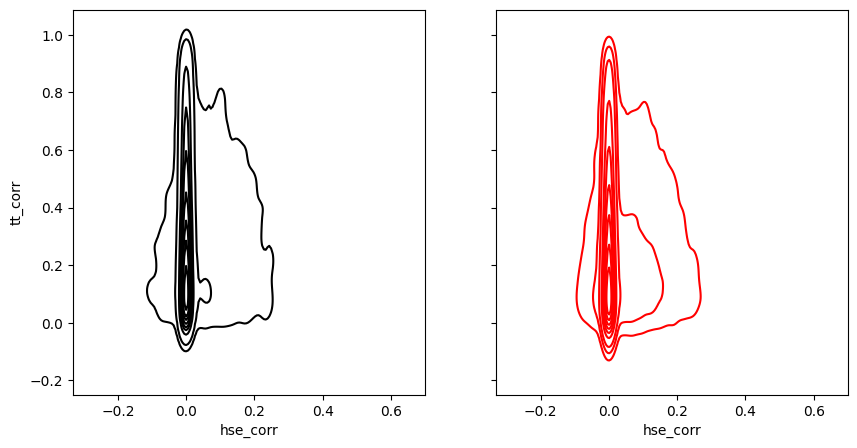

In [57]:
fig, ax = plt.subplots(1,2, figsize=(10,5), sharex=True, sharey=True)

_ = sns.kdeplot(data=df.loc[~cre_mask], 
            x='hse_corr', 
            y='tt_corr',
            color='black',
            ax=ax[0])
print(sp.stats.spearmanr(df.loc[~cre_mask*nonzero_mask,'hse_corr'], df.loc[~cre_mask*nonzero_mask,'tt_corr']))

_ = sns.kdeplot(data=df.loc[cre_mask], 
            x='hse_corr', 
            y='tt_corr',
            color='red',
            ax=ax[1])
print(sp.stats.spearmanr(df.loc[cre_mask*nonzero_mask,'hse_corr'], df.loc[cre_mask*nonzero_mask,'tt_corr']))





In [53]:
import statsmodels.formula.api as smf
df_tmp = df.copy()
df_tmp['condition'] = df_tmp['condition'].astype('category')
df_tmp['mouse'] = df_tmp['mouse'].astype('category')
df_tmp['hse_day'] = df_tmp['hse_day'].astype('category')
df_tmp['tt_day'] = df_tmp['tt_day'].astype('category')
df_tmp['hse_corr_rank'] = df_tmp['hse_corr'].rank()
df_tmp['tt_corr_rank'] = df_tmp['tt_corr'].rank()
model = smf.mixedlm("tt_corr_rank ~ hse_corr_rank * condition + hse_day + tt_day", df_tmp, groups=df_tmp["mouse"])

In [54]:
res = model.fit()
res.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                        Mixed Linear Model Regression Results
======================================================================================
Model:                     MixedLM         Dependent Variable:         tt_corr_rank   
No. Observations:          143823          Method:                     REML           
No. Groups:                16              Scale:                      1648352380.7246
Min. group size:           678             Log-Likelihood:             -1730236.2358  
Max. group size:           15650           Converged:                  Yes            
Mean group size:           8988.9                                                     
--------------------------------------------------------------------------------------
                                   Coef.     Std.Err.   z    P>|z|   [0.025    0.975] 
--------------------------------------------------------------------------------------
Intercept                          58691.096 3799.405 15.447 0.000 51244.398 66137.794
condition[T.ctrl]                   2377.778 5039.701  0.472 0.637 -7499.855 12255.410
hse_day[T.1]                         846.705  301.543  2.808 0.005   255.693  1437.718
hse_day[T.2]                         814.351  338.202  2.408 0.016   151.486  1477.215
hse_day[T.3]                        1020.693  387.649  2.633 0.008   260.915  1780.472
hse_day[T.4]                        1774.711  493.771  3.594 0.000   806.938  2742.484
tt_day[T.2]                         4207.797  537.792  7.824 0.000  3153.744  5261.849
tt_day[T.3]                         8629.964  519.187 16.622 0.000  7612.376  9647.552
tt_day[T.4]                         8326.388  514.748 16.176 0.000  7317.501  9335.275
tt_day[T.5]                         8153.896  514.388 15.852 0.000  7145.713  9162.079
hse_corr_rank                          0.022    0.005  4.426 0.000     0.012     0.032
hse_corr_rank:condition[T.ctrl]        0.036    0.007  5.106 0.000     0.022     0.050
Group Var                       98633209.998  939.619                                 
======================================================================================

"""

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 143823.
  res = hypotest_fun_out(*samples, **kwds)


Shapiro-Wilk: W=0.965, p=7.23e-92
D'Agostino: χ²=76142.984, p=0


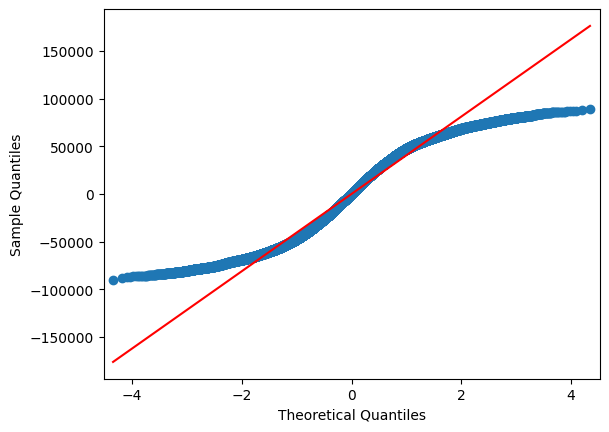

In [55]:
import statsmodels.api as sm
from scipy.stats import shapiro, normaltest, anderson

fig = sm.qqplot(res.resid, line ='s')

# Shapiro-Wilk test (good for small–moderate n)
shapiro_test = shapiro(res.resid)
print(f"Shapiro-Wilk: W={shapiro_test.statistic:.3f}, p={shapiro_test.pvalue:.3g}")

# D’Agostino and Pearson omnibus test (good for larger n)
dagostino_test = normaltest(res.resid)
print(f"D'Agostino: χ²={dagostino_test.statistic:.3f}, p={dagostino_test.pvalue:.3g}")

In [ ]:
df_nonactive

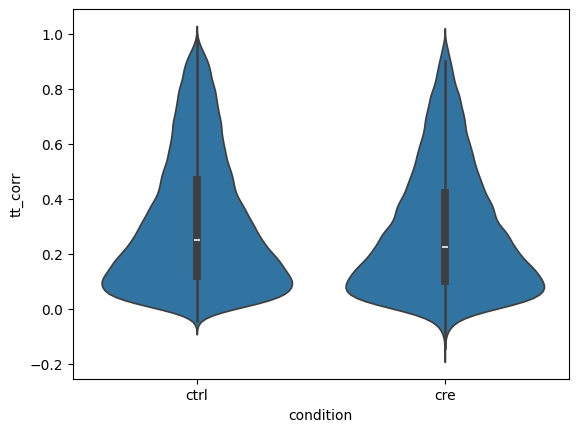

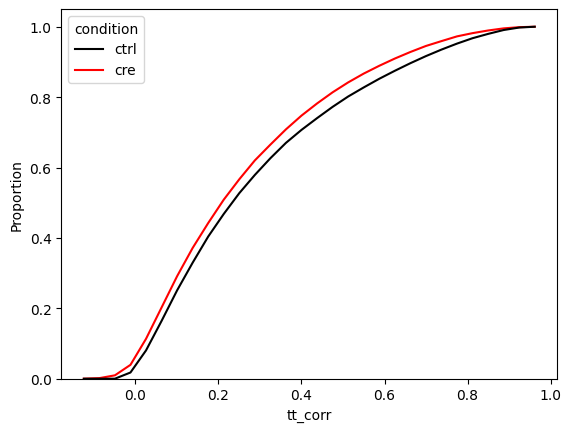

In [23]:

fig, ax = plt.subplots()
_ = sns.violinplot(data=df, x='condition', y='tt_corr', ax=ax)

fig, ax = plt.subplots()
_ = sns.histplot(data=df,
                x = 'tt_corr',
                hue = 'condition',
                hue_order=['ctrl','cre'],
                palette=['black','red'],
                bins=30,
                cumulative=True,
                fill=False,
                common_norm=False,
                element='poly',
                stat='proportion',
                ax=ax)

In [ ]:

fig, ax = plt.subplots()
_ = sns.violinplot(data=df, x='condition', y='hse_corr', ax=ax)

fig, ax = plt.subplots()
_ = sns.histplot(data=df,
                x = 'tt_corr',
                hue = 'condition',
                hue_order=['ctrl','cre'],
                palette=['black','red'],
                bins=30,
                cumulative=True,
                fill=False,
                common_norm=False,
                element='poly',
                stat='proportion',
                ax=ax)

In [29]:
cre_mask = df['condition']=='cre'
nonzero_mask = df['hse_corr']>0
print(df.loc[cre_mask*nonzero_mask,'tt_corr'].mean(), df.loc[cre_mask*(~nonzero_mask),'tt_corr'].mean())
print(df.loc[~cre_mask*nonzero_mask,'tt_corr'].mean(), df.loc[~cre_mask*(~nonzero_mask),'tt_corr'].mean())

0.28865739211522196 0.27994957661112074
0.3380658254946667 0.30899030858567617


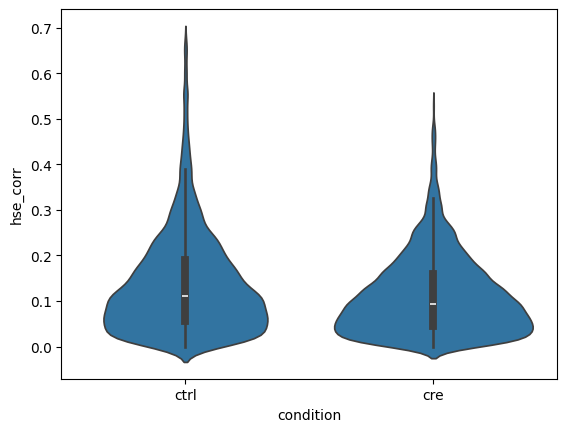

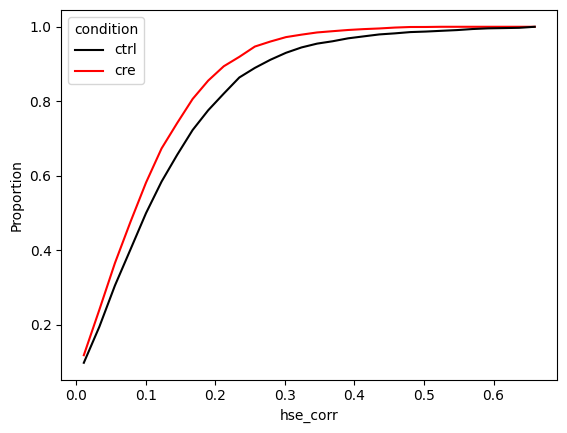

In [30]:
fig, ax = plt.subplots()
_ = sns.violinplot(data=df.loc[nonzero_mask,:], x='condition', y='hse_corr', ax=ax)

fig, ax = plt.subplots()
_ = sns.histplot(data=df.loc[nonzero_mask,:],
                x = 'hse_corr',
                hue = 'condition',
                hue_order=['ctrl','cre'],
                palette=['black','red'],
                bins=30,
                cumulative=True,
                fill=False,
                common_norm=False,
                element='poly',
                stat='proportion',
                ax=ax)

In [96]:
#  load single replay session
cond_key = 'ctrl'
mouse = ctrl_mice[0]
day=0

with open(hse_dict[cond_key][day][mouse], 'rb') as file:
    hse = pickle.load(file)


/tmp/ipykernel_206885/2814508288.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(novel_pop_act, cell_act[cell,mask])


(array([ 1.,  2.,  1.,  3.,  5.,  8.,  5., 12., 18., 19., 14., 27., 12.,
        25., 13., 15.,  5., 10.,  5., 10.,  2.,  8.,  1.,  2.,  0.,  0.,
         0.,  0.,  0.,  1.]),
 array([-0.19491389, -0.1714639 , -0.14801392, -0.12456394, -0.10111395,
        -0.07766397, -0.05421398, -0.030764  , -0.00731402,  0.01613597,
         0.03958595,  0.06303594,  0.08648592,  0.1099359 ,  0.13338589,
         0.15683587,  0.18028586,  0.20373584,  0.22718582,  0.25063581,
         0.27408579,  0.29753578,  0.32098576,  0.34443574,  0.36788573,
         0.39133571,  0.4147857 ,  0.43823568,  0.46168566,  0.48513565,
         0.50858563]),
 <BarContainer object of 30 artists>)

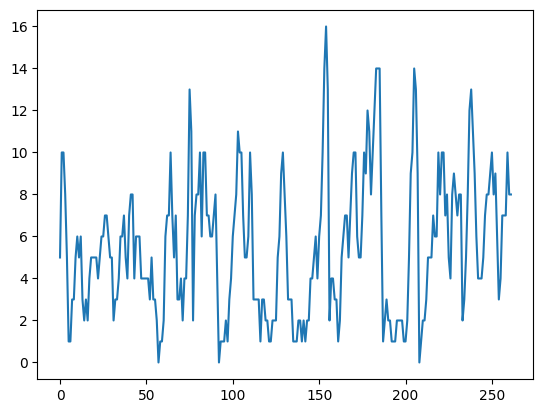

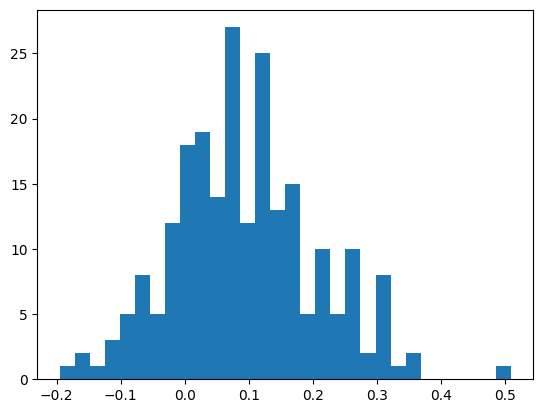

In [41]:
fig, ax = plt.subplots()
# print(hse.spks_th.shape)
# hse.post_reward_bool
mask = (hse.post_reward_bool>0)*(hse.lr==hse.novel_arm)
novel_pop_act = hse.pop_coactivity_boxcar[mask]
ax.plot(novel_pop_act)

cell_act = hse.post_reward_activation_boxcar
corr = []
for cell in range(cell_act.shape[0]):
    r,_ = sp.stats.pearsonr(novel_pop_act, cell_act[cell,mask])
    corr.append(r)
corr = np.array(corr)


fig, ax = plt.subplots()
ax.hist(corr, bins=30)


/tmp/ipykernel_44315/2934518741.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse.activation_mask.sum(axis=0)[np.newaxis,hse.post_reward_bool>0],spks_ledge[:,hse.post_reward_bool>0], axis=-1)


[[ 1.         -0.83255802 -0.56931043 -0.31240202 -0.62115443  0.23651202
   0.2650433  -0.59833078  0.1470983  -0.4743586   0.70048997  0.01027596
  -0.26709065 -0.01975718  0.01424911 -0.43344236 -0.33316859 -0.13559541
   0.94545644 -0.44341076]
 [-0.83255802  1.          0.53251352  0.07840336  0.43929303 -0.34642046
  -0.39619595  0.69060429 -0.16904494  0.29128207 -0.72808433 -0.0783378
   0.23789169 -0.01179561 -0.02965857  0.55500388  0.27197575 -0.00230879
  -0.90460557  0.39354115]
 [-0.56931043  0.53251352  1.          0.29287272  0.06012932  0.00873388
  -0.09506257  0.49188151 -0.11082794  0.2373627  -0.26952606 -0.04909987
   0.61106915 -0.12087293  0.12326204  0.09026689  0.09033884  0.21617516
  -0.49301609  0.11361174]
 [-0.31240202  0.07840336  0.29287272  1.          0.4544213   0.44487205
   0.21658689  0.28321802 -0.04213645  0.52736912  0.04913724 -0.14898721
   0.32054976 -0.04560236  0.4215293  -0.25719881  0.42224286  0.46770369
  -0.10274346 -0.05397614]
 [-0.

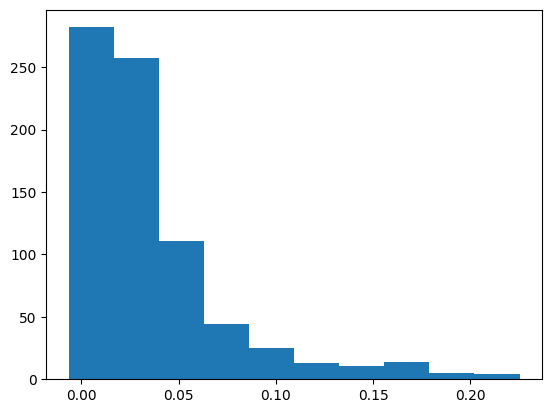

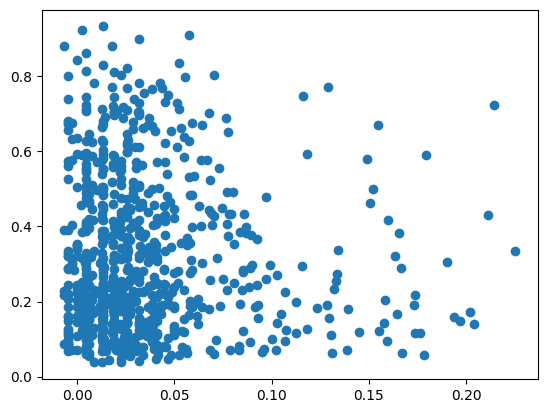

In [31]:
spks_ledge = 1*(np.diff(1.*(hse.spks_th>0),prepend=0,axis=-1)>0)


r,_ = sp.stats.pearsonr(hse.activation_mask.sum(axis=0)[np.newaxis,hse.post_reward_bool>0],spks_ledge[:,hse.post_reward_bool>0], axis=-1)

fig, ax = plt.subplots()
ax.hist(r)


nov_trial_mask = hse.trial_info['LR'] == hse.novel_arm

nov_trial_mat = hse.trial_mat[nov_trial_mask,:,:]
nov_trial_mat[np.isnan(nov_trial_mat)]=0
nov_corr_mat = np.zeros([nov_trial_mat.shape[0], nov_trial_mat.shape[0], nov_trial_mat.shape[-1]])

for cell in range(nov_trial_mat.shape[-1]):
    nov_corr_mat[:,:,cell] = np.corrcoef(nov_trial_mat[:,:,cell])

fig, ax = plt.subplots()
ax.scatter(r, nov_corr_mat.mean(axis=0).mean(axis=0))
print(nov_corr_mat[:,:,0])


In [ ]:
#  concatenate all postreward reactivation